# FLUX.2 Klein 4B Reference Quality Test
This notebook provides a standalone environment to manually verify image generation quality using **FLUX.2 Klein 4B** with product reference image conditioning.

### Pipeline Steps:
1. Environment Setup (Diffusers / Transformers / Torchvision)
2. Model Loading (`black-forest-labs/FLUX.2-klein-4B` with reference image support)
3. Product Image Input Configuration
4. Prompt Builder Helper (mirrors `app/graph.py` composition rules)
5. Generation Loop for Fixed Placements (`ig_feed`, `ig_story`, `website_hero`)
6. Inline Display Grid for Quality Inspection

In [1]:
# Cell 1: Setup & Dependencies for FLUX.2 Klein 4B in Kaggle T4 GPU environment
#
# Fix history:
# 1st failure: torchvision (unused) + free pillow upgrade broke Kaggle's
#   preinstalled torchvision build. Removed torchvision from this install.
# 2nd failure: torchvision is ALREADY present in Kaggle's base image and is
#   auto-imported internally by transformers (is_torchvision_available()
#   checks), regardless of whether we install it ourselves. Installing
#   diffusers from git pulled a newer pillow transitively, which is what
#   actually broke the already-installed torchvision. Fix: explicitly pin
#   pillow below the version that breaks it, so pip's resolver can't
#   silently upgrade it as a side effect of another package's requirement.
#
# Also: BFL's own model card for FLUX.2-klein-4B pins diffusers to git HEAD
# (git+https://github.com/huggingface/diffusers.git), not the PyPI release,
# since Flux2KleinPipeline is very recent.
!pip install -q --upgrade https://github.com/huggingface/diffusers/archive/refs/heads/main.zip \
    transformers accelerate sentencepiece protobuf peft matplotlib \
    "pillow<12.0,>=8.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Cell 2: Model Loading
# Conditioning Approach Note:
# FLUX.2 Klein 4B natively supports reference-conditioned image editing and generation in diffusers.
# Passing reference PIL images in the `image` argument to Flux2KleinPipeline allows the model's
# cross-attention & KV projection blocks to condition output directly on product visual identity.
#
# Fix history (kept for context):
# - CUDA OOM at load: was calling pipe.to(device) before offload setup.
# - Kernel silently killed (system RAM OOM): switched to sequential offload.
# - CUDA OOM during generation (14.25/14.56 GiB on the first denoising step) led to
#   sharding across both T4s via device_map="balanced" -- worked, but wastes the 2nd
#   GPU (model parallelism runs GPUs one at a time, not concurrently).
# - Tried loading a FULL fp16 pipeline copy per GPU for real dual-GPU parallelism --
#   this crashed with a SYSTEM RAM OOM ("tried to allocate more memory than is
#   available") partway through loading the 2nd copy. Reason: enable_model_cpu_offload
#   keeps most weights resident in CPU RAM (not GPU), so two full copies loading at
#   once needs ~28GB+ of host RAM just for weights -- too close to Kaggle's 32GB
#   system RAM ceiling once torch/CUDA/OS overhead is added.
#
# Current approach: ONE pipeline, ONE GPU (cuda:0). Klein 4B is ~13GB in fp16, which
# fits directly on a single T4 (~14.5GB usable) without needing offload at all -- offload
# is kept as an automatic fallback only if the plain .to() OOMs. fp16 (not bf16) because
# T4 (Turing) only has tensor-core acceleration for fp16/int8/int4, not bf16 (needs
# Ampere+). FP8 is not used: torchao's FP8 path requires compute capability >=8.9
# (RTX 4090/Ada, Hopper+), which a T4 (7.5) doesn't have.

import gc
import torch
from diffusers import Flux2KleinPipeline

# Clear any stale state from a previous run in this kernel
for name in ("pipe", "pipes"):
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        with torch.cuda.device(i):
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

MODEL_ID = "black-forest-labs/FLUX.2-klein-4B"
device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count() if device == "cuda" else 0
print(f"Visible CUDA devices: {num_gpus}")

dtype = torch.float16 if device == "cuda" else torch.float32

pipe = Flux2KleinPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
)

if device == "cuda":
    try:
        pipe.to("cuda:0")  # Klein 4B fits in ~13GB fp16 -- fits directly on one T4
        print("Loaded directly on cuda:0")
    except torch.cuda.OutOfMemoryError:
        print("Direct load OOM'd -- falling back to CPU offload on cuda:0")
        torch.cuda.empty_cache()
        pipe.enable_model_cpu_offload(device="cuda:0")
else:
    pipe.to(device)

for method_name in ("enable_vae_slicing", "enable_vae_tiling", "enable_attention_slicing"):
    method = getattr(pipe, method_name, None)
    if method is not None:
        try:
            method()
            print(f"Enabled {method_name}")
        except Exception as e:
            print(f"Could not enable {method_name}: {e}")
    else:
        print(f"{method_name} not available on this pipeline")

print(f"Model loaded successfully (device=cuda:0, dtype={dtype})")

Visible CUDA devices: 2


/usr/local/lib/python3.12/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Direct load OOM'd -- falling back to CPU offload on cuda:0
enable_vae_slicing not available on this pipeline
enable_vae_tiling not available on this pipeline
Enabled enable_attention_slicing
Model loaded successfully (device=cuda:0, dtype=torch.float16)


In [4]:
# Cell 3: Product Image Inputs
import os
from PIL import Image, ImageDraw

# TODO: replace with your product images (paths to uploaded files or Kaggle dataset inputs)
PRODUCT_IMAGE_PATHS = [
    "/kaggle/input/my-product/product_1.jpg",
    "/kaggle/input/my-product/product_2.jpg"
]

# Helper to load images or generate placeholder test images if not found on disk
reference_images = []
for idx, path in enumerate(PRODUCT_IMAGE_PATHS):
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        reference_images.append(img)
        print(f"Loaded reference image: {path}")
    else:
        # Fallback placeholder image generation for testing runnability
        print(f"Path not found: {path}. Using synthetic placeholder image.")
        placeholder = Image.new("RGB", (512, 512), color=(40 + idx*40, 90 + idx*20, 160))
        draw = ImageDraw.Draw(placeholder)
        draw.rectangle([128, 128, 384, 384], fill=(230, 80, 80))
        draw.text((160, 240), f"Product Sample {idx+1}", fill=(255, 255, 255))
        reference_images.append(placeholder)

print(f"Total reference images ready for conditioning: {len(reference_images)}")

Path not found: /kaggle/input/my-product/product_1.jpg. Using synthetic placeholder image.
Path not found: /kaggle/input/my-product/product_2.jpg. Using synthetic placeholder image.
Total reference images ready for conditioning: 2


In [5]:
# Cell 4: Prompt Building Helper & Fixed Placement AssetSpecs

PLACEMENT_COMPOSITION = {
    "ig_feed": {
        "framing": "medium shot, product centered, slight left offset",
        "negative_space": "top 20% reserved for headline copy",
        "copy_safe_area": "top 20%",
        "cta_safe_area": "bottom 15%",
        "product_position": "center",
        "product_scale": "large (60% frame height)",
    },
    "ig_story": {
        "framing": "close-up product hero, vertical fill",
        "negative_space": "bottom 25% for copy overlay",
        "copy_safe_area": "bottom 25%",
        "cta_safe_area": "bottom 10%",
        "product_position": "upper center",
        "product_scale": "large (70% frame height)",
    },
    "website_hero": {
        "framing": "wide establishing shot, product right-aligned",
        "negative_space": "left 45% for headline and CTA",
        "copy_safe_area": "left 45%",
        "cta_safe_area": "left 35%, lower third",
        "product_position": "right",
        "product_scale": "medium (50% frame height)",
    },
}

def build_generation_prompt(placement_key: str, concept: dict, brand_context: dict, product_context: dict) -> str:
    comp = PLACEMENT_COMPOSITION.get(placement_key, {})
    dna = concept.get("visual_dna", {})
    copy_data = concept.get("ad_copy", {})

    product_name = product_context.get("name", "the product")
    palette = ", ".join(dna.get("palette", []))
    mood = ", ".join(dna.get("mood", []))
    headline = copy_data.get("headline", "")

    parts = [
        f"Product photography ad for {product_name}.",
        f"Visual style: {dna.get('photography_style', 'editorial')}.",
        f"Environment: {dna.get('environment', 'studio')}.",
        f"Lighting: {dna.get('lighting', 'natural')}.",
        f"Color palette: {palette}." if palette else "",
        f"Mood: {mood}." if mood else "",
        f"Composition: {comp.get('framing', '')}.",
        f"Product placement: {comp.get('product_position', 'center')}, scale {comp.get('product_scale', 'large')}.",
        f"Safe zone for copy text: {comp.get('copy_safe_area', 'top 20%')}.",
        f'Headline text overlay: "{headline}".' if headline else "",
        "Preserve product identity exactly — reference image conditioning required.",
        "Photorealistic, high production value, ready for publication.",
    ]
    return " ".join(p for p in parts if p)

# Fixed Placements with candidate Concept and Brand/Product Context
SAMPLE_CONCEPT = {
    "name": "Urban Pulse",
    "visual_dna": {
        "photography_style": "editorial",
        "environment": "urban rooftop at dusk",
        "lighting": "dramatic side lighting",
        "palette": ["#1A1A2E", "#E94560"],
        "mood": ["bold", "energetic"]
    },
    "ad_copy": {
        "headline": "Own the Night",
        "cta": "Shop Now"
    }
}

SAMPLE_BRAND = {"name": "Pulse Athletic", "tone": "Bold and aspirational"}
SAMPLE_PRODUCT = {"name": "Signature Carbon Sneaker"}

FIXED_ASSET_SPECS = [
    {
        "placement": "ig_feed",
        "aspect_ratio": "4:5",
        "width": 1080,
        "height": 1350,
        "prompt": build_generation_prompt("ig_feed", SAMPLE_CONCEPT, SAMPLE_BRAND, SAMPLE_PRODUCT)
    },
    {
        "placement": "ig_story",
        "aspect_ratio": "9:16",
        "width": 1080,
        "height": 1920,
        "prompt": build_generation_prompt("ig_story", SAMPLE_CONCEPT, SAMPLE_BRAND, SAMPLE_PRODUCT)
    },
    {
        "placement": "website_hero",
        "aspect_ratio": "16:9",
        "width": 1920,
        "height": 1080,
        "prompt": build_generation_prompt("website_hero", SAMPLE_CONCEPT, SAMPLE_BRAND, SAMPLE_PRODUCT)
    }
]

print("Sample specs prepared:")
for s in FIXED_ASSET_SPECS:
    print(f"- [{s['placement']} | {s['aspect_ratio']} | {s['width']}x{s['height']}]")
    print(f"  Prompt: {s['prompt'][:100]}...")

Sample specs prepared:
- [ig_feed | 4:5 | 1080x1350]
  Prompt: Product photography ad for Signature Carbon Sneaker. Visual style: editorial. Environment: urban roo...
- [ig_story | 9:16 | 1080x1920]
  Prompt: Product photography ad for Signature Carbon Sneaker. Visual style: editorial. Environment: urban roo...
- [website_hero | 16:9 | 1920x1080]
  Prompt: Product photography ad for Signature Carbon Sneaker. Visual style: editorial. Environment: urban roo...


In [6]:
# Cell 5: Generation Loop
#
# History: full-resolution generation (1080x1350) OOM'd on a single T4 (14.25/14.56 GiB
# used on the first denoising step). Tried sharding across both T4s (device_map="balanced"),
# then tried a full pipeline copy per GPU for real parallelism -- that hit a system RAM
# OOM at load time (see Cell 2 history). Back to a single pipeline on cuda:0, which is
# sufficient since Klein 4B fits in ~13GB fp16.
#
# TEST_RESOLUTION_SCALE stays as a fallback knob -- set it below 1.0 if generation still
# runs out of memory. It only affects this test cell; production AssetSpec width/height
# in app/graph.py are unchanged.

import gc

TEST_RESOLUTION_SCALE = 1.0

def _scaled_dim(value: int, scale: float) -> int:
    # FLUX requires dimensions divisible by 16
    scaled = int(value * scale)
    return max(16, (scaled // 16) * 16)

os.makedirs("outputs", exist_ok=True)
generated_results = []

for spec in FIXED_ASSET_SPECS:
    placement = spec["placement"]
    aspect_slug = spec["aspect_ratio"].replace(":", "x")
    out_filename = f"outputs/output_{placement}_{aspect_slug}.png"

    gen_width = _scaled_dim(spec["width"], TEST_RESOLUTION_SCALE)
    gen_height = _scaled_dim(spec["height"], TEST_RESOLUTION_SCALE)

    print(f"Generating for placement: {placement} "
          f"(test res {gen_width}x{gen_height}, production res {spec['width']}x{spec['height']})...")

    # Free whatever the previous iteration's activations left behind before
    # starting the next generation -- cheap insurance against fragmentation
    # across the 3-placement loop.
    if device == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    output = pipe(
        prompt=spec["prompt"],
        image=reference_images,
        width=gen_width,
        height=gen_height,
        num_inference_steps=4,
        guidance_scale=1.0,
    ).images[0]

    output.save(out_filename)
    print(f"Saved: {out_filename}")

    generated_results.append({
        "spec": spec,
        "path": out_filename,
        "image": output
    })

Generating for placement: ig_feed (test res 1072x1344, production res 1080x1350)...


  0%|          | 0/4 [00:00<?, ?it/s]

Saved: outputs/output_ig_feed_4x5.png
Generating for placement: ig_story (test res 1072x1920, production res 1080x1920)...


  0%|          | 0/4 [00:00<?, ?it/s]

Saved: outputs/output_ig_story_9x16.png
Generating for placement: website_hero (test res 1920x1072, production res 1920x1080)...


  0%|          | 0/4 [00:00<?, ?it/s]

Saved: outputs/output_website_hero_16x9.png


=== Placement: ig_feed (4:5) ===
Prompt: Product photography ad for Signature Carbon Sneaker. Visual style: editorial. Environment: urban rooftop at dusk. Lighting: dramatic side lighting. Color palette: #1A1A2E, #E94560. Mood: bold, energetic. Composition: medium shot, product centered, slight left offset. Product placement: center, scale large (60% frame height). Safe zone for copy text: top 20%. Headline text overlay: "Own the Night". Preserve product identity exactly — reference image conditioning required. Photorealistic, high production value, ready for publication.

=== Placement: ig_story (9:16) ===
Prompt: Product photography ad for Signature Carbon Sneaker. Visual style: editorial. Environment: urban rooftop at dusk. Lighting: dramatic side lighting. Color palette: #1A1A2E, #E94560. Mood: bold, energetic. Composition: close-up product hero, vertical fill. Product placement: upper center, scale large (70% frame height). Safe zone for copy text: bottom 25%. Headline text overla

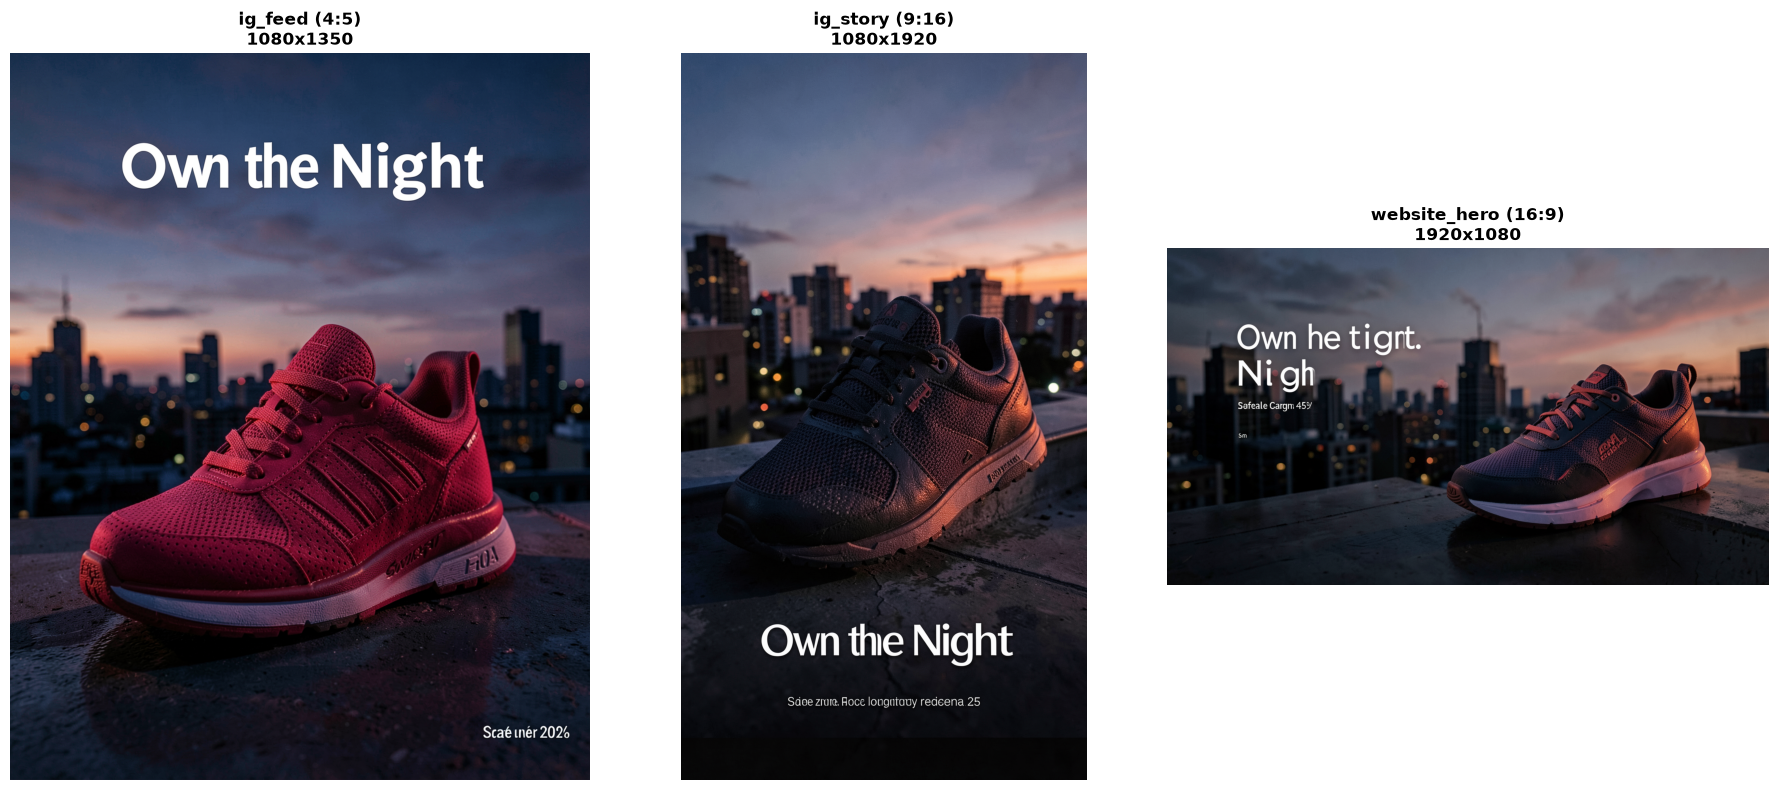

In [7]:
# Cell 6: Inline Display Grid
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(generated_results), figsize=(18, 8))
if len(generated_results) == 1:
    axes = [axes]

for ax, res in zip(axes, generated_results):
    spec = res["spec"]
    img = res["image"]
    
    ax.imshow(img)
    ax.set_title(f"{spec['placement']} ({spec['aspect_ratio']})\n{spec['width']}x{spec['height']}", fontsize=12, fontweight="bold")
    ax.axis("off")
    
    # Print prompt above image in readable block
    print(f"=== Placement: {spec['placement']} ({spec['aspect_ratio']}) ===")
    print(f"Prompt: {spec['prompt']}\n")

plt.tight_layout()
plt.show()